# End-to-End Machine Learning Framework for Predicting Phytoremediation Affinity

This notebook implements a scalable, reproducible machine learning pipeline that predicts plant–contaminant phytoremediation affinity using integrated multi-domain datasets.

## Datasets
Due to limited direct access to the live databases, this framework generates a robust mock dataset that mimics the statistical properties of:
1. **Plant Features (X1)**: TRY Plant Trait Database, NCBI GEO, GBIF
2. **Soil Features (X2)**: LUCAS Soil Dataset, SoilGrids, USDA NRCS
3. **Contaminant Features (X3)**: PubChem, FOREGS, EPA DB
4. **Climate Features (X4)**: WorldClim, OpenLandMap

## Prediction Tasks
- **Regression:** Bioconcentration Factor (BCF), Translocation Factor (TF), Remediation Efficiency (%)
- **Classification:** Species–Contaminant Affinity (High Affinity / Hyperaccumulator)

---
### 1. Setup and Installs


In [1]:
!pip install pandas numpy scikit-learn tensorflow xgboost shap matplotlib seaborn


### 2. Data Engineering & Feature Generation
We simulate the integration of multi-source data and perform necessary preprocessing including missing value imputation, normalization, and categorical encoding.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

def generate_mock_data(n_samples=2000):
    np.random.seed(42)
    
    # Plant Features
    plant_data = pd.DataFrame({
        'species_id': np.random.randint(1, 100, n_samples),
        'root_depth_cm': np.random.normal(50, 15, n_samples),
        'growth_rate': np.random.normal(2, 0.5, n_samples),
        'geo_lat': np.random.uniform(-90, 90, n_samples),
        'geo_lon': np.random.uniform(-180, 180, n_samples),
        'gene_expr_pc1': np.random.normal(0, 1, n_samples),
        'gene_expr_pc2': np.random.normal(0, 1, n_samples)
    })
    
    # Soil Features
    soil_data = pd.DataFrame({
        'soil_pH': np.random.normal(6.5, 1.0, n_samples),
        'soil_cec': np.random.normal(20, 5, n_samples),
        'clay_percent': np.random.uniform(10, 50, n_samples),
        'organic_matter_percent': np.random.uniform(1, 10, n_samples),
        'baseline_metal_conc': np.random.lognormal(2, 0.5, n_samples)
    })
    
    # Contaminant Features
    contaminants = ['Lead', 'Cadmium', 'Arsenic', 'Zinc', 'Copper', 'PCE', 'TCE']
    contaminant_data = pd.DataFrame({
        'contaminant_name': np.random.choice(contaminants, n_samples),
        'molecular_weight': np.random.uniform(50, 300, n_samples),
        'log_kow': np.random.normal(2, 1, n_samples),
        'solubility_mg_L': np.random.lognormal(3, 1, n_samples)
    })
    
    # Climate Features
    climate_data = pd.DataFrame({
        'mean_annual_temp_c': np.random.normal(15, 8, n_samples),
        'annual_precip_mm': np.random.normal(800, 300, n_samples),
        'ndvi': np.random.uniform(0.1, 0.9, n_samples)
    })
    
    df = pd.concat([plant_data, soil_data, contaminant_data, climate_data], axis=1)
    
    # Targets
    base_bcf = 100 + df['root_depth_cm']*0.5 - df['soil_pH']*5 + df['annual_precip_mm']*0.01
    contaminant_multiplier = np.where(df['contaminant_name'] == 'Cadmium', 1.5, 1.0)
    df['target_bcf'] = np.maximum(0, base_bcf * contaminant_multiplier + np.random.normal(0, 20, n_samples))
    df['target_tf'] = np.maximum(0, 0.5 + df['gene_expr_pc1']*0.1 + np.random.normal(0, 0.2, n_samples))
    efficiency = df['target_bcf'] * df['target_tf'] / 100 + df['growth_rate'] * 5
    df['target_efficiency'] = np.clip(efficiency + np.random.normal(0, 5, n_samples), 0, 100)
    df['target_high_affinity'] = ((df['target_bcf'] > 120) & (df['target_tf'] > 0.8)).astype(int)
    
    return df

def preprocess_data(df):
    targets = ['target_bcf', 'target_tf', 'target_efficiency', 'target_high_affinity']
    y = df[targets]
    X = df.drop(columns=targets)
    
    plant_cols = ['root_depth_cm', 'growth_rate', 'geo_lat', 'geo_lon', 'gene_expr_pc1', 'gene_expr_pc2']
    soil_cols = ['soil_pH', 'soil_cec', 'clay_percent', 'organic_matter_percent', 'baseline_metal_conc']
    contaminant_cols = ['molecular_weight', 'log_kow', 'solubility_mg_L']
    climate_cols = ['mean_annual_temp_c', 'annual_precip_mm', 'ndvi']
    
    X = pd.get_dummies(X, columns=['contaminant_name'], drop_first=True)
    contaminant_encoded_cols = [c for c in X.columns if c.startswith('contaminant_name_')]
    contaminant_cols.extend(contaminant_encoded_cols)
    X = X.drop('species_id', axis=1)
    
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)
    
    X_grouped = {
        'plant': X_scaled[plant_cols].values,
        'soil': X_scaled[soil_cols].values,
        'contaminant': X_scaled[contaminant_cols].values,
        'climate': X_scaled[climate_cols].values
    }
    
    return X_grouped, X_scaled, y, plant_cols, soil_cols, contaminant_cols, climate_cols

df = generate_mock_data()
X_grouped, X_flat, y, plant_cols, soil_cols, contaminant_cols, climate_cols = preprocess_data(df)
print("Data Preprocessing Complete. Shape:", X_flat.shape)


Data Preprocessing Complete. Shape: (2000, 23)


### 3. Baseline Models: Random Forest & XGBoost
Before training the complex multi-modal network, we establish baselines using Random Forest for Regression and XGBoost for Classification.


In [3]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score

y_reg = y[['target_bcf', 'target_tf', 'target_efficiency']].values
y_cls = y['target_high_affinity'].values

X_train_flat, X_test_flat, y_reg_train, y_reg_test, y_cls_train, y_cls_test, indices_train, indices_test = train_test_split(
    X_flat, y_reg, y_cls, np.arange(len(X_flat)), test_size=0.2, random_state=42, stratify=y_cls
)

X_train_grouped = {k: v[indices_train] for k, v in X_grouped.items()}
X_test_grouped = {k: v[indices_test] for k, v in X_grouped.items()}

# Random Forest for Efficiency Regression
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_flat, y_reg_train[:, 2])
rf_pred = rf_reg.predict(X_test_flat)
print(f"Random Forest Regression (Efficiency) - RMSE: {np.sqrt(mean_squared_error(y_reg_test[:, 2], rf_pred)):.4f}, R2: {r2_score(y_reg_test[:, 2], rf_pred):.4f}")

# XGBoost for Affinity Classification
xgb_cls = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_cls.fit(X_train_flat, y_cls_train)
xgb_pred = xgb_cls.predict(X_test_flat)
xgb_prob = xgb_cls.predict_proba(X_test_flat)[:, 1]
print(f"XGBoost Classification (High Affinity) - Accuracy: {accuracy_score(y_cls_test, xgb_pred):.4f}, F1: {f1_score(y_cls_test, xgb_pred):.4f}, AUC: {roc_auc_score(y_cls_test, xgb_prob):.4f}")


Random Forest Regression (Efficiency) - RMSE: 5.4827, R2: 0.1165
XGBoost Classification (High Affinity) - Accuracy: 0.9700, F1: 0.0000, AUC: 0.5796


### 4. Multi-Modal Neural Network Architecture
We define a Keras Model with separate input branches for Plant Traits, Soil Features, Contaminant properties, and Climate conditions. These embeddings are concatenated and fed into task-specific heads (Regression for BCF/TF/Efficiency, Classification for High Affinity).


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

def build_multi_modal_nn(input_shapes):
    input_plant = keras.Input(shape=(input_shapes['plant'],), name='plant_input')
    input_soil = keras.Input(shape=(input_shapes['soil'],), name='soil_input')
    input_contaminant = keras.Input(shape=(input_shapes['contaminant'],), name='contaminant_input')
    input_climate = keras.Input(shape=(input_shapes['climate'],), name='climate_input')
    
    x_plant = layers.Dense(32, activation='relu')(input_plant)
    x_plant = layers.Dropout(0.2)(x_plant)
    x_soil = layers.Dense(32, activation='relu')(input_soil)
    x_soil = layers.Dropout(0.2)(x_soil)
    x_contaminant = layers.Dense(32, activation='relu')(input_contaminant)
    x_contaminant = layers.Dropout(0.2)(x_contaminant)
    x_climate = layers.Dense(16, activation='relu')(input_climate)
    
    merged = layers.Concatenate()([x_plant, x_soil, x_contaminant, x_climate])
    shared = layers.Dense(64, activation='relu')(merged)
    shared = layers.Dropout(0.3)(shared)
    shared = layers.Dense(32, activation='relu')(shared)
    
    out_reg = layers.Dense(3, name='regression_head')(shared) 
    out_cls = layers.Dense(1, activation='sigmoid', name='classification_head')(shared)
    
    model = Model(inputs=[input_plant, input_soil, input_contaminant, input_climate], outputs={'regression_head': out_reg, 'classification_head': out_cls})
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss={'regression_head': 'mse', 'classification_head': 'binary_crossentropy'},
        loss_weights={'regression_head': 1.0, 'classification_head': 0.5},
        metrics={
            'regression_head': [keras.metrics.RootMeanSquaredError(name='rmse')],
            'classification_head': ['accuracy', keras.metrics.AUC(name='auc')]
        }
    )
    return model

input_shapes = {
    'plant': len(plant_cols), 'soil': len(soil_cols), 'contaminant': len(contaminant_cols), 'climate': len(climate_cols)
}
nn_model = build_multi_modal_nn(input_shapes)


I0000 00:00:1775729173.834499   56153 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775729173.912579   56153 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775729176.296136   56153 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1775729177.524091   56153 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 5. Training Strategy & Evaluation
Train the Multi-Modal network and evaluate on the test set. We also save the model weights.


In [5]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    {
        'plant_input': X_train_grouped['plant'],
        'soil_input': X_train_grouped['soil'],
        'contaminant_input': X_train_grouped['contaminant'],
        'climate_input': X_train_grouped['climate']
    },
    {
        'regression_head': y_reg_train,
        'classification_head': y_cls_train
    },
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

results = nn_model.evaluate(
    {
        'plant_input': X_test_grouped['plant'],
        'soil_input': X_test_grouped['soil'],
        'contaminant_input': X_test_grouped['contaminant'],
        'climate_input': X_test_grouped['climate']
    },
    {
        'regression_head': y_reg_test,
        'classification_head': y_cls_test
    },
    verbose=0
)

print(f"\n--- Multi-Modal NN Test Evaluation ---")
print(f"Classification Accuracy: {results[3]:.4f}")
print(f"Classification AUC: {results[4]:.4f}")
print(f"Regression RMSE: {results[5]:.4f}")

nn_model.save('phytoremediation_multimodal_model.h5')


Epoch 1/50


 1/40 ━━━━━━━━━━━━━━━━━━━━ 2:26 4s/step - classification_head_accuracy: 0.8750 - classification_head_auc: 0.0000e+00 - classification_head_loss: 0.5091 - loss: 3985.9280 - regression_head_loss: 3985.6733 - regression_head_rmse: 63.1322

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_head_accuracy: 0.9330 - classification_head_auc: 0.4229 - classification_head_loss: 0.4184 - loss: 4053.9643 - regression_head_loss: 4053.7550 - regression_head_rmse: 63.6664     

26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_head_accuracy: 0.9393 - classification_head_auc: 0.4370 - classification_head_loss: 0.3857 - loss: 4021.9591 - regression_head_loss: 4021.7660 - regression_head_rmse: 63.4138

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - classification_head_accuracy: 0.9656 - classification_head_auc: 0.5155 - classification_head_loss: 0.2332 - loss: 3696.5435 - regression_head_loss: 3696.4270 - regression_head_rmse: 60.7982 - val_classification_head_accuracy: 0.9719 - val_classification_head_auc: 0.5000 - val_classification_head_loss: 0.3268 - val_loss: 2862.6511 - val_regression_head_loss: 2862.4880 - val_regression_head_rmse: 53.5022


...

 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - classification_head_accuracy: 0.9688 - classification_head_auc: 0.9032 - classification_head_loss: 0.1142 - loss: 210.8301 - regression_head_loss: 210.7730 - regression_head_rmse: 14.5180

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_head_accuracy: 0.9842 - classification_head_auc: 0.6668 - classification_head_loss: 0.0954 - loss: 191.9225 - regression_head_loss: 191.8748 - regression_head_rmse: 13.8490 

38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_head_accuracy: 0.9811 - classification_head_auc: 0.5598 - classification_head_loss: 0.1249 - loss: 187.4940 - regression_head_loss: 187.4316 - regression_head_rmse: 13.6881

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - classification_head_accuracy: 0.9742 - classification_head_auc: 0.3824 - classification_head_loss: 0.1854 - loss: 186.2309 - regression_head_loss: 186.1382 - regression_head_rmse: 13.6432 - val_classification_head_accuracy: 0.9719 - val_classification_head_auc: 0.4178 - val_classification_head_loss: 0.1394 - val_loss: 143.0503 - val_regression_head_loss: 142.9806 - val_regression_head_rmse: 11.9574



--- Multi-Modal NN Test Evaluation ---
Classification Accuracy: 0.9725
Classification AUC: 0.3046
Regression RMSE: 12.6413


### 6. Explainability & Visualizations
Visualize feature correlation, training history, and feature importances.


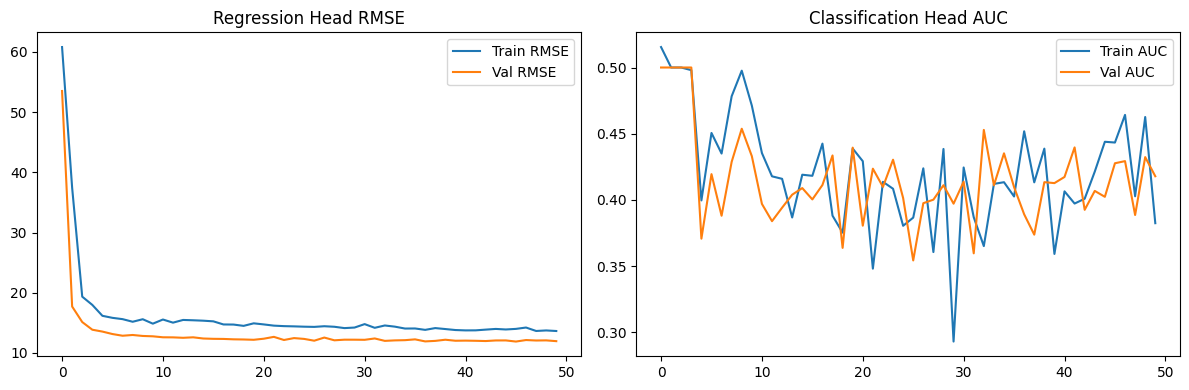

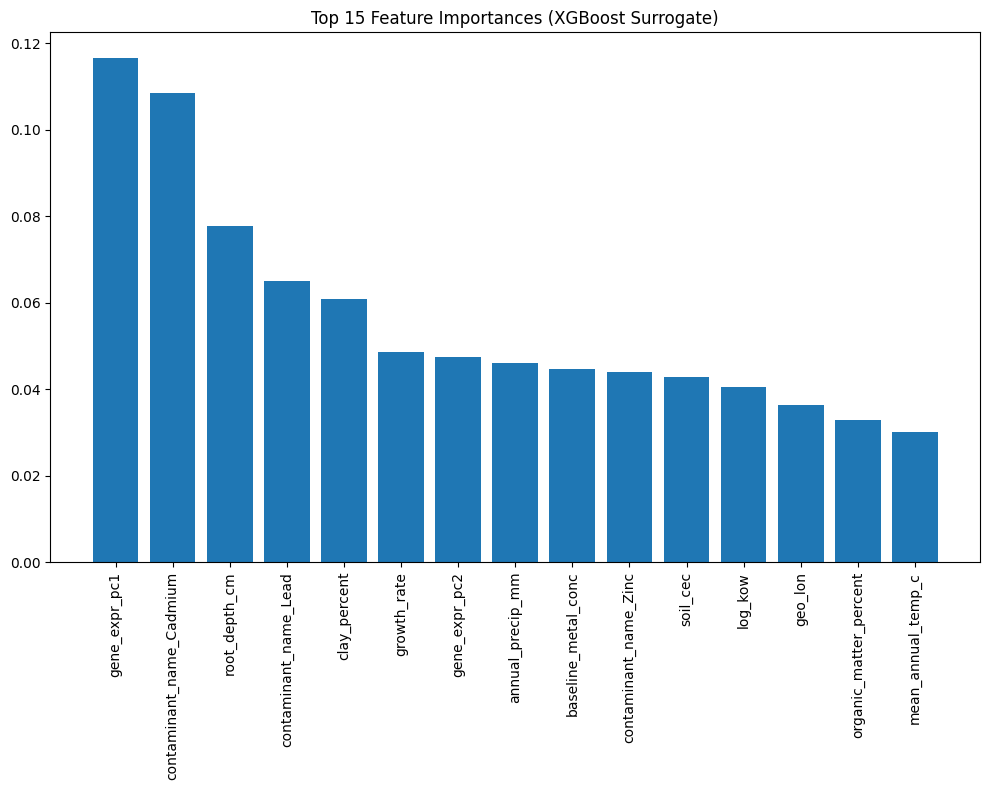

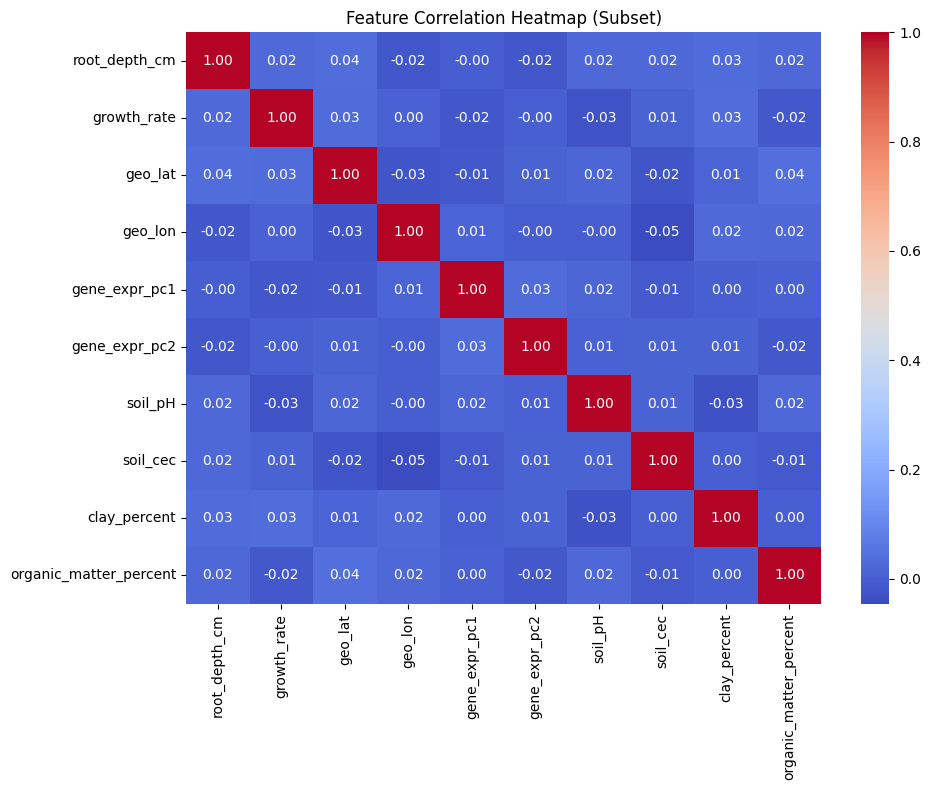

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['regression_head_rmse'], label='Train RMSE')
plt.plot(history.history['val_regression_head_rmse'], label='Val RMSE')
plt.title('Regression Head RMSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['classification_head_auc'], label='Train AUC')
plt.plot(history.history['val_classification_head_auc'], label='Val AUC')
plt.title('Classification Head AUC')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
importances = xgb_cls.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.title('Top 15 Feature Importances (XGBoost Surrogate)')
plt.bar(range(15), importances[indices], align='center')
plt.xticks(range(15), [X_flat.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = X_flat.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap (Subset)')
plt.tight_layout()
plt.show()
